<a href="https://colab.research.google.com/github/vyenn/ML2024/blob/main/test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multitask Shape Classification and Regression (With Plots)

This notebook trains a single neural network to perform two tasks:
1.  **Classification**: Identify which pair of 135 possible shape combinations is in the image.
2.  **Regression**: Predict the exact count (out of 10) for each of the 6 shape types.

**Experiments**: We evaluate Classification-only, Regression-only, and Multitask settings, including **plots for losses, accuracy, and RMSE**.

## 0. Setup and Data Download

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
import os
import random
from sklearn.metrics import f1_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


def set_seed(seed_value):
    """Sets seeds for reproducibility across Python, NumPy, and PyTorch."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(1)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [16]:
if not os.path.exists('data'):
    print("Data directory 'data' not found. Downloading...")
    !wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
    !unzip data_gsn.zip &> /dev/null
    !rm data_gsn.zip
    print("Download and unzip complete.")
else:
    print("Data directory 'data' already exists. Skipping download.")

Data directory 'data' already exists. Skipping download.


## 1. Data Preparation

In [17]:
def get_count_to_class_map():
    """Generates the mapping from a 6-dim count tuple to a class ID."""
    count_to_class_id = {}
    class_id = 0
    for i in range(6):
        for j in range(i + 1, 6):
            for count_i in range(1, 10):
                count_j = 10 - count_i
                counts = [0] * 6
                counts[i] = count_i
                counts[j] = count_j
                count_to_class_id[tuple(counts)] = class_id
                class_id += 1
    return count_to_class_id

count_to_class_id_map = get_count_to_class_map()
class_id_to_counts_map = {v: k for k, v in count_to_class_id_map.items()}

# Map for Per-pair Accuracy
class_id_to_pair = {}
for class_id in range(len(class_id_to_counts_map)):
    counts = class_id_to_counts_map[class_id]
    indices = [i for i, count in enumerate(counts) if count > 0]
    pair = frozenset(indices)
    class_id_to_pair[class_id] = pair

### Dataset class

In [18]:
class MyDataset(Dataset):
    def __init__(self, csv_path, img_dir, count_to_class_id_map, train=True):
        self.img_dir = img_dir
        self.train = train
        self.map = count_to_class_id_map

        df = pd.read_csv(csv_path)
        if self.train:
            self.labels_df = df.iloc[:9000]
        else:
            self.labels_df = df.iloc[9000:]

        # Shape indices: 0:sq, 1:circ, 2:up, 3:right, 4:down, 5:left
        self.h_flip_map = {3: 5, 5: 3}
        self.v_flip_map = {2: 4, 4: 2}
        self.rot90_map = {2: 3, 3: 4, 4: 5, 5: 2}

    def __len__(self):
        return len(self.labels_df)

    def _transform_counts(self, counts_tensor, mapping):
        new_counts = counts_tensor.clone()
        for k, v in mapping.items():
            new_counts[v] = counts_tensor[k]
        return new_counts

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_name = row['name']
        img_path = os.path.join(self.img_dir, img_name)

        base_image = Image.open(img_path).convert('L')
        base_counts = torch.tensor(row[1:].values.astype(float), dtype=torch.float32)

        # Default to original
        image = base_image
        counts = base_counts

        if self.train:
            # Randomly select one augmentation: 0=Original, 1=HFlip, 2=VFlip, 3=Rot90
            aug_idx = random.randint(0, 3)
            #aug_idx = random.choices([0, 1, 2, 3], weights=[91, 3, 3, 3], k=1)[0]
            #aug_idx = 0

            if aug_idx == 1:
                # Horizontal Flip
                image = base_image.transpose(Image.FLIP_LEFT_RIGHT)
                counts = self._transform_counts(base_counts, self.h_flip_map)
            elif aug_idx == 2:
                # Vertical Flip
                image = base_image.transpose(Image.FLIP_TOP_BOTTOM)
                counts = self._transform_counts(base_counts, self.v_flip_map)
            elif aug_idx == 3:
                # 90-degree CW Rotation
                image = base_image.rotate(-90)
                counts = self._transform_counts(base_counts, self.rot90_map)
            # else aug_idx == 0: keep original

        # Process the selected image
        img_tensor = torch.tensor(np.array(image), dtype=torch.float32).unsqueeze(0) / 255.0

        # Get label
        class_key = tuple(counts.int().tolist())
        class_label = self.map[class_key]

        # We use unsqueeze(0) to add the extra dimension (size 1)
        # so it matches the shape expected by code that previously handled a stack of 4.
        return img_tensor.unsqueeze(0), torch.tensor([class_label], dtype=torch.long), counts.unsqueeze(0)

### Data loaders initialization

In [19]:
IMG_DIR = "data"
CSV_PATH = os.path.join(IMG_DIR, "labels.csv")
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_VAL = 1000

train_dataset = MyDataset(CSV_PATH, IMG_DIR, count_to_class_id_map, train=True)
val_dataset = MyDataset(CSV_PATH, IMG_DIR, count_to_class_id_map, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_VAL, shuffle=False)

## 2. Model Definition

In [20]:
class MultiTaskModel(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
            nn.Flatten(start_dim=1),
            nn.Linear(64 * 28 * 28, 256), nn.ReLU()
        )
        self.head_cls = nn.Linear(256, 135)
        self.head_cnt = nn.Linear(256, 6)
        self.log_softmax = nn.LogSoftmax(dim=1)
        self.dropout = nn.Dropout(p)
        # self.bn = nn.BatchNorm1d(256)

    def forward(self, x):
        features = self.backbone(x)
        features_norm = features
        # features_norm = self.bn(features)
        features_dropped = self.dropout(features_norm)
        logits_cls = self.head_cls(features_dropped)
        log_probs = self.log_softmax(logits_cls)
        counts = self.head_cnt(features_dropped)
        return log_probs, counts

## 3. Training with early stopping

In [21]:
class EarlyStopping:
    def __init__(self, patience=20, delta=0, path='best_model.pth'):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_model(model, lambda_cnt, lambda_cls, train_loader, val_loader, device, n_epochs=100):
    print(f"\nStarting training | lambda_cls={lambda_cls} | lambda_cnt={lambda_cnt}")

    criterion_cls = nn.NLLLoss()
    criterion_cnt = nn.SmoothL1Loss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    save_path = f'best_model_cls{lambda_cls}_cnt{lambda_cnt}.pth'
    early_stopping = EarlyStopping(patience=20, path=save_path)

    model.to(device)

    # History storage
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_rmse': []
    }

    for epoch in range(1, n_epochs + 1):
        # --- Training ---
        model.train()
        train_loss = 0.0
        total_train = 0

        for images, labels_cls, labels_cnt in train_loader:
            images = images.view(-1, 1, 28, 28).to(device)
            labels_cls = labels_cls.view(-1).to(device)
            labels_cnt = labels_cnt.view(-1, 6).to(device)

            optimizer.zero_grad()
            log_probs, counts = model(images)

            loss_cls = criterion_cls(log_probs, labels_cls)
            loss_cnt = criterion_cnt(counts, labels_cnt)
            loss = (lambda_cls * loss_cls) + (lambda_cnt * loss_cnt)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            total_train += images.size(0)

        avg_train_loss = train_loss / total_train

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        total_val = 0

        # Metric tracking buffers
        all_val_preds_cls = []
        all_val_labels_cls = []
        all_val_preds_cnt = []
        all_val_labels_cnt = []

        with torch.no_grad():
            for images, labels_cls, labels_cnt in val_loader:
                images = images.view(-1, 1, 28, 28).to(device)
                labels_cls = labels_cls.view(-1).to(device)
                labels_cnt = labels_cnt.view(-1, 6).to(device)

                log_probs, counts = model(images)

                loss_cls = criterion_cls(log_probs, labels_cls)
                loss_cnt = criterion_cnt(counts, labels_cnt)
                loss = (lambda_cls * loss_cls) + (lambda_cnt * loss_cnt)

                val_loss += loss.item() * images.size(0)
                total_val += images.size(0)

                # Store predictions for metrics
                _, preds_cls = torch.max(log_probs, 1)
                all_val_preds_cls.append(preds_cls.cpu())
                all_val_labels_cls.append(labels_cls.cpu())
                all_val_preds_cnt.append(counts.cpu())
                all_val_labels_cnt.append(labels_cnt.cpu())

        avg_val_loss = val_loss / total_val

        # Compute Epoch Metrics
        y_pred_cls = torch.cat(all_val_preds_cls).numpy()
        y_true_cls = torch.cat(all_val_labels_cls).numpy()
        y_pred_cnt = torch.cat(all_val_preds_cnt).numpy()
        y_true_cnt = torch.cat(all_val_labels_cnt).numpy()

        val_acc = 100 * (y_pred_cls == y_true_cls).mean()
        val_rmse = np.sqrt(mean_squared_error(y_true_cnt, y_pred_cnt))

        # Update history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_rmse'].append(val_rmse)

        early_stopping(avg_val_loss, model)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(torch.load(save_path))
    return model, history

## 4. Plotting and Evaluation Functions

In [22]:
def plot_training_history(history, title="no title"):
    """Plots Loss, Accuracy, and RMSE from the training history."""
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{title} - Training History', fontsize=16)

    # 1. Losses
    axs[0].plot(history['train_loss'], label='Train Loss')
    axs[0].plot(history['val_loss'], label='Val Loss')
    axs[0].set_title('Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # 2. Accuracy
    axs[1].plot(history['val_acc'], label='Val Top-1 Acc', color='green')
    axs[1].set_title('Validation Classification Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy (%)')
    axs[1].legend()
    axs[1].grid(True)

    # 3. RMSE
    axs[2].plot(history['val_rmse'], label='Val RMSE', color='red')
    axs[2].set_title('Validation Regression RMSE')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('RMSE')
    axs[2].legend()
    axs[2].grid(True)

    plt.show()

In [23]:
def evaluate_model(model, val_loader, device):
    """Evaluates the model and returns the final requested metrics."""
    model.eval()
    all_preds_cls, all_labels_cls = [], []
    all_preds_cnt, all_labels_cnt = [], []

    with torch.no_grad():
        for images, labels_cls, labels_cnt in val_loader:
            images = images.view(-1, 1, 28, 28).to(device)
            labels_cls = labels_cls.view(-1).to(device)
            labels_cnt = labels_cnt.view(-1, 6).to(device)

            log_probs, counts = model(images)
            _, preds_cls = torch.max(log_probs, 1)

            all_preds_cls.append(preds_cls.cpu())
            all_labels_cls.append(labels_cls.cpu())
            all_preds_cnt.append(counts.cpu())
            all_labels_cnt.append(labels_cnt.cpu())

    y_pred_cls = torch.cat(all_preds_cls).numpy()
    y_true_cls = torch.cat(all_labels_cls).numpy()
    y_pred_cnt = torch.cat(all_preds_cnt).numpy()
    y_true_cnt = torch.cat(all_labels_cnt).numpy()

    # 1. Top-1 Accuracy
    top1_acc = 100 * (y_pred_cls == y_true_cls).mean()

    # 2. Macro F1 Score
    macro_f1 = f1_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)

    # 3. Per-pair Accuracy
    pair_correct = 0
    for i in range(len(y_true_cls)):
        true_pair = class_id_to_pair.get(y_true_cls[i])
        pred_pair = class_id_to_pair.get(y_pred_cls[i])
        if true_pair == pred_pair:
            pair_correct += 1
    pair_acc = 100 * pair_correct / len(y_true_cls)

    # 4. MAE (Overall)
    mae = mean_absolute_error(y_true_cnt, y_pred_cnt)

    # 5. MSE (Overall)
    mse = mean_squared_error(y_true_cnt, y_pred_cnt)

    return {
        "Top1 Acc (%)": top1_acc,
        "Macro F1": macro_f1,
        "Per-pair Acc (%)": pair_acc,
        "MAE": mae,
        "MSE": mse
    }

## 5. Main Experiment Loop

We run the three settings. For each setting, we train, plot the history immediately, evaluate on the validation set, and store the results.

At the end we present metrics for different settings in the table.

In [24]:
"""settings = [
    {"name": "Classification-only", "lambda_cls": 1.0, "lambda_cnt": 0.0},
    {"name": "Regression-only",     "lambda_cls": 0.0, "lambda_cnt": 1.0},
    {"name": "Multitask",           "lambda_cls": 1.0, "lambda_cnt": 1.0},
]

results = []

for setting in settings:
    # Initialize fresh model
    model = MultiTaskModel()

    # Train
    best_model, history = train_model(
        model,
        lambda_cnt=setting["lambda_cnt"],
        lambda_cls=setting["lambda_cls"],
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        n_epochs=100
    )

    # Plot History
    plot_training_history(history, setting["name"])

    # Evaluate Final Metrics
    metrics = evaluate_model(best_model, val_loader, device)

    # Store results
    row = {"Model": setting["name"]}
    row.update(metrics)
    results.append(row)"""

'settings = [{"name": "Multitask",           "lambda_cls": 1.0, "lambda_cnt": 1.0}]\n\nresults = []\n\nfor setting in settings:\n    # Initialize fresh model\n    model = MultiTaskModel()\n\n    # Train\n    best_model, history = train_model(\n        model,\n        lambda_cnt=setting["lambda_cnt"],\n        lambda_cls=setting["lambda_cls"],\n        train_loader=train_loader,\n        val_loader=val_loader,\n        device=device,\n        n_epochs=100\n    )\n\n    # Plot History\n    plot_training_history(history, setting["name"])\n\n    # Evaluate Final Metrics\n    metrics = evaluate_model(best_model, val_loader, device)\n\n    # Store results\n    row = {"Model": setting["name"]}\n    row.update(metrics)\n    results.append(row)'

Rozpoczynam eksperymenty dla dropoutów: [0.9]

 >>> TESTING DROPOUT p=0.9

Starting training | lambda_cls=1.0 | lambda_cnt=1.0
Epoch 1/100 | Train Loss: 6.3108 | Val Loss: 6.1588
Epoch 5/100 | Train Loss: 6.1211 | Val Loss: 6.0693
Epoch 10/100 | Train Loss: 5.5346 | Val Loss: 5.0311
Epoch 15/100 | Train Loss: 5.2175 | Val Loss: 4.4361
Epoch 20/100 | Train Loss: 4.9805 | Val Loss: 4.1242
Epoch 25/100 | Train Loss: 4.8446 | Val Loss: 3.8450
Epoch 30/100 | Train Loss: 4.7132 | Val Loss: 3.6751
Epoch 35/100 | Train Loss: 4.5196 | Val Loss: 3.3893
Epoch 40/100 | Train Loss: 4.2943 | Val Loss: 3.1583
Epoch 45/100 | Train Loss: 4.2154 | Val Loss: 3.0828
Epoch 50/100 | Train Loss: 4.0346 | Val Loss: 2.8546
Epoch 55/100 | Train Loss: 3.9395 | Val Loss: 2.7766
Epoch 60/100 | Train Loss: 3.8644 | Val Loss: 2.6010
Epoch 65/100 | Train Loss: 3.7771 | Val Loss: 2.5398
Epoch 70/100 | Train Loss: 3.7034 | Val Loss: 2.4121
Epoch 75/100 | Train Loss: 3.6465 | Val Loss: 2.3399
Epoch 80/100 | Train Loss: 

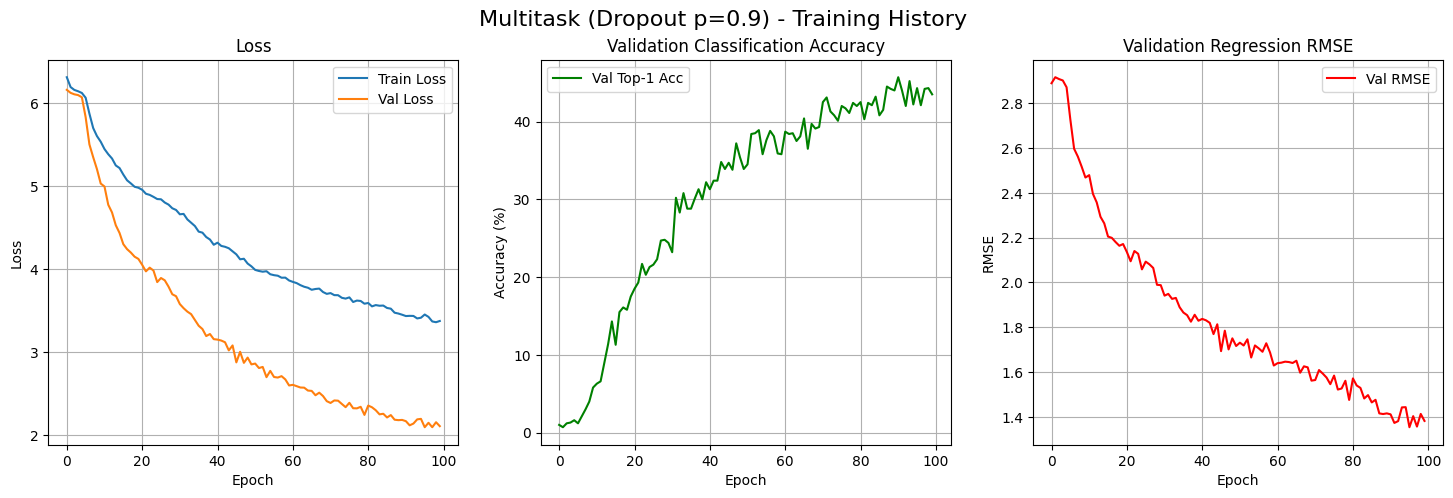


FINAL EVALUATION RESULTS (ALL DROPOUTS)


Model,Dropout,Top1 Acc (%),Macro F1,Per-pair Acc (%),MAE,MSE
Multitask,0.900000,44.20,0.3884,96.40,0.9149,1.8424


In [26]:
from IPython.display import display
import pandas as pd


settings = [
    {"name": "Classification-only", "lambda_cls": 1.0, "lambda_cnt": 0.0},
    {"name": "Regression-only",     "lambda_cls": 0.0, "lambda_cnt": 1.0},
    {"name": "Multitask",           "lambda_cls": 1.0, "lambda_cnt": 1.0},
]

dropout_values = [0.5]

results = []

print(f"Rozpoczynam eksperymenty dla dropoutów: {dropout_values}")


for p in dropout_values:
    print(f"\n" + "="*40)
    print(f" >>> TESTING DROPOUT p={p}")
    print("="*40)

    for setting in settings:
        set_seed(1) # for reproducibility

        model = MultiTaskModel(p=p)

        # Train
        best_model, history = train_model(
            model,
            lambda_cnt=setting["lambda_cnt"],
            lambda_cls=setting["lambda_cls"],
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            n_epochs=100
        )

        # Plot History
        plot_title = f"{setting['name']} (Dropout p={p})"
        plot_training_history(history, plot_title)

        # Evaluate Final Metrics
        metrics = evaluate_model(best_model, val_loader, device)

        # Store results
        row = {
            "Model": setting["name"],
            "Dropout": p
        }
        row.update(metrics)
        results.append(row)

# --- Final Results Table ---
results_df = pd.DataFrame(results)

# Format for readibility
results_df["Top1 Acc (%)"] = results_df["Top1 Acc (%)"].apply(lambda x: f"{x:.2f}")
results_df["Macro F1"] = results_df["Macro F1"].apply(lambda x: f"{x:.4f}")
results_df["Per-pair Acc (%)"] = results_df["Per-pair Acc (%)"].apply(lambda x: f"{x:.2f}")
results_df["MAE"] = results_df["MAE"].apply(lambda x: f"{x:.4f}")
results_df["MSE"] = results_df["MSE"].apply(lambda x: f"{x:.4f}")


results_df_sorted = results_df.sort_values(by=["Model", "Dropout"])

print("\n" + "="*80)
print("FINAL EVALUATION RESULTS (ALL DROPOUTS)")
print("="*80)

# Display
display(results_df_sorted.style.hide(axis='index'))